This notebook serves as a place containing my work for homework 4

# Question 1.)

 Build three models for FBS team evaluation: an SRS model of score differential only, an opponent adjusted game control model, and an opponent adjusted average win probability (awp) model.  Give the top 10 and botton 10 teams for each season from 2021 to 2025.

In [1]:
# import neccesary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
from IPython.display import display, Markdown
import sportsdataverse as sdv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

# SRS model (score differential only)

In [2]:
# define the season range
seasons = range(2021, 2026)
games_list = []

for season in seasons:
    url = f"https://raw.githubusercontent.com/sportsdataverse/cfbfastR-data/main/schedules/csv/cfb_schedules_{season}.csv"
    df_season = pd.read_csv(url)
    games_list.append(df_season)

raw_games = pd.concat(games_list, ignore_index=True)

# Clean and filter for completed games with valid scores
games_clean = raw_games[
    (raw_games['completed'] == True) &
    (raw_games['home_points'].notna()) &
    (raw_games['away_division']=='fbs') &
    (raw_games['away_points'].notna()) &
    (raw_games['season_type'].isin(['regular']))
][['season', 'week', 'home_team', 'away_team', 'home_points', 'away_points']].sort_values(['season', 'week']).reset_index(drop=True)

In [3]:
# Make an SRS function
def calc_srs_scratch(df):
    # Reset index to guarantee alignment with 0..n_games range
    df = df.reset_index(drop=True)
    
    teams = np.unique(np.concatenate([df['home_team'].unique(), df['away_team'].unique()]))
    n_games = len(df)
    
    X = pd.DataFrame(0.0, index=range(n_games), columns=teams)
    
    for i, row in df.iterrows():
        X.loc[i, row['home_team']] = 1.0
        X.loc[i, row['away_team']] = -1.0
        
    margin = df['home_points'] - df['away_points']
    X = sm.add_constant(X)
    fit = sm.OLS(margin, X).fit()
    srs_vec = fit.params.fillna(0)
    srs_centered = srs_vec - srs_vec.mean()
    
    return pd.DataFrame({
        'team': srs_centered.index,
        'SRS': np.round(srs_centered.values, 2)
    })

In [4]:
# calculate SRS for each season
def compute_season_ratings(season_df):
    year = season_df['season'].iloc[0]
    srs_df = calc_srs_scratch(season_df)
    srs_df['season'] = year
    return srs_df.sort_values(by='SRS', ascending=False).reset_index(drop=True)

# Execute loop across split season datasets
ratings_list = []
for year, season_df in games_clean.groupby('season'):
    ratings_list.append(compute_season_ratings(season_df))

ratings_by_season = pd.concat(ratings_list, ignore_index=True)

C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uni

In [5]:
# List top 10 teams by SRS for each season
for yr in sorted(ratings_by_season['season'].unique()):
    top_rankings = (
        ratings_by_season[ratings_by_season['season'] == yr]
        .sort_values(by='SRS', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    top_rankings['Rank'] = top_rankings.index + 1
    
    top_rankings = top_rankings[[
        'Rank', 'team', 'SRS'
    ]].rename(columns={
        'team': 'Team',
        'SRS': 'SRS Rating',
    })
    
    display(Markdown(f"### Top 10 Teams by SRS for Season: {yr}"))
    display(Markdown(top_rankings.to_markdown(index=False)))

### Top 10 Teams by SRS for Season: 2021

|   Rank | Team           |   SRS Rating |
|-------:|:---------------|-------------:|
|      1 | Georgia        |        35.58 |
|      2 | Alabama        |        29.23 |
|      3 | Ohio State     |        28.62 |
|      4 | Michigan       |        25.77 |
|      5 | Notre Dame     |        21.67 |
|      6 | Oklahoma State |        19.92 |
|      7 | Utah           |        19.82 |
|      8 | Cincinnati     |        19.35 |
|      9 | Iowa State     |        17.16 |
|     10 | Wisconsin      |        16.57 |

### Top 10 Teams by SRS for Season: 2022

|   Rank | Team         |   SRS Rating |
|-------:|:-------------|-------------:|
|      1 | Georgia      |        33.86 |
|      2 | Tennessee    |        30.29 |
|      3 | Alabama      |        29.76 |
|      4 | Ohio State   |        29.22 |
|      5 | Michigan     |        28.03 |
|      6 | Texas        |        25.14 |
|      7 | Kansas State |        24.52 |
|      8 | TCU          |        23.58 |
|      9 | Penn State   |        22.47 |
|     10 | Utah         |        20.41 |

### Top 10 Teams by SRS for Season: 2023

|   Rank | Team          |   SRS Rating |
|-------:|:--------------|-------------:|
|      1 | Michigan      |        30.28 |
|      2 | Oregon        |        29.97 |
|      3 | Ohio State    |        28.46 |
|      4 | Penn State    |        27.53 |
|      5 | Oklahoma      |        25.83 |
|      6 | Texas         |        25.66 |
|      7 | Georgia       |        24.26 |
|      8 | Notre Dame    |        23.39 |
|      9 | Kansas State  |        22.73 |
|     10 | Florida State |        22.38 |

### Top 10 Teams by SRS for Season: 2024

|   Rank | Team           |   SRS Rating |
|-------:|:---------------|-------------:|
|      1 | Notre Dame     |        27.95 |
|      2 | Texas          |        27.33 |
|      3 | Ohio State     |        27.14 |
|      4 | Alabama        |        25.71 |
|      5 | Ole Miss       |        24.5  |
|      6 | Indiana        |        23.38 |
|      7 | Georgia        |        22.95 |
|      8 | Tennessee      |        22.64 |
|      9 | Oregon         |        22.63 |
|     10 | South Carolina |        21.74 |

### Top 10 Teams by SRS for Season: 2025

|   Rank | Team       |   SRS Rating |
|-------:|:-----------|-------------:|
|      1 | Indiana    |        37.28 |
|      2 | Ohio State |        32.5  |
|      3 | Texas Tech |        31.9  |
|      4 | Oregon     |        30.13 |
|      5 | Notre Dame |        29.44 |
|      6 | Utah       |        25.56 |
|      7 | Miami      |        24.63 |
|      8 | Georgia    |        22.46 |
|      9 | USC        |        21.54 |
|     10 | Iowa       |        21.02 |

In [6]:
# List bottom 10 teams by SRS for each season
for yr in sorted(ratings_by_season['season'].unique()):
    bottom_rankings = (
        ratings_by_season[ratings_by_season['season'] == yr]
        .sort_values(by='SRS', ascending=True)
        .head(10)
        .reset_index(drop=True)
    )
    bottom_rankings['Rank'] = bottom_rankings.index + 1
    
    bottom_rankings = bottom_rankings[[
        'Rank', 'team', 'SRS'
    ]].rename(columns={
        'team': 'Team',
        'SRS': 'SRS Rating',
    })
    
    display(Markdown(f"### Bottom 10 Teams by SRS for Season: {yr}"))
    display(Markdown(bottom_rankings.to_markdown(index=False)))

### Bottom 10 Teams by SRS for Season: 2021

|   Rank | Team                  |   SRS Rating |
|-------:|:----------------------|-------------:|
|      1 | Florida International |       -33.09 |
|      2 | Jacksonville State    |       -32.51 |
|      3 | Massachusetts         |       -30.72 |
|      4 | Akron                 |       -29.86 |
|      5 | Temple                |       -28.79 |
|      6 | UConn                 |       -28.02 |
|      7 | Southern Miss         |       -22.21 |
|      8 | New Mexico State      |       -21.6  |
|      9 | Arkansas State        |       -21.33 |
|     10 | Duke                  |       -20.71 |

### Bottom 10 Teams by SRS for Season: 2022

|   Rank | Team                  |   SRS Rating |
|-------:|:----------------------|-------------:|
|      1 | Florida International |       -32.56 |
|      2 | Massachusetts         |       -29.01 |
|      3 | New Mexico            |       -24.59 |
|      4 | Charlotte             |       -23.77 |
|      5 | Hawai'i               |       -23.42 |
|      6 | Louisiana Tech        |       -20.61 |
|      7 | New Mexico State      |       -20.21 |
|      8 | Nevada                |       -19.8  |
|      9 | Colorado              |       -19.49 |
|     10 | Akron                 |       -18.54 |

### Bottom 10 Teams by SRS for Season: 2023

|   Rank | Team                  |   SRS Rating |
|-------:|:----------------------|-------------:|
|      1 | Kent State            |       -32.03 |
|      2 | Temple                |       -25.42 |
|      3 | Akron                 |       -24.01 |
|      4 | UL Monroe             |       -21.87 |
|      5 | Florida International |       -20.77 |
|      6 | Massachusetts         |       -20.18 |
|      7 | Eastern Michigan      |       -19.15 |
|      8 | Charlotte             |       -18.8  |
|      9 | Nevada                |       -18.68 |
|     10 | Southern Miss         |       -17.91 |

### Bottom 10 Teams by SRS for Season: 2024

|   Rank | Team             |   SRS Rating |
|-------:|:-----------------|-------------:|
|      1 | Kent State       |       -34.84 |
|      2 | Tulsa            |       -32.78 |
|      3 | Southern Miss    |       -29    |
|      4 | Middle Tennessee |       -26.85 |
|      5 | New Mexico State |       -26.72 |
|      6 | Kennesaw State   |       -26.32 |
|      7 | UTEP             |       -23.2  |
|      8 | Temple           |       -21.88 |
|      9 | Ball State       |       -21.04 |
|     10 | Central Michigan |       -20.98 |

### Bottom 10 Teams by SRS for Season: 2025

|   Rank | Team          |   SRS Rating |
|-------:|:--------------|-------------:|
|      1 | Massachusetts |       -37.85 |
|      2 | Sam Houston   |       -28.88 |
|      3 | UL Monroe     |       -25.6  |
|      4 | Charlotte     |       -24.65 |
|      5 | Georgia State |       -23.24 |
|      6 | Akron         |       -22.99 |
|      7 | Ball State    |       -22.58 |
|      8 | UTEP          |       -20.7  |
|      9 | Kent State    |       -20.29 |
|     10 | Rice          |       -19.27 |

In [40]:
def compute_week_ratings(season_df, season, week):
    """Compute SRS using only games played *before* this week (no leakage)."""
    games_so_far = season_df[season_df['week'] < week]
    
    # skip if not enough games yet to solve SRS meaningfully
    if games_so_far.empty:
        return None
    
    srs_df = calc_srs_scratch(games_so_far)
    srs_df['season'] = season
    srs_df['week'] = week
    return srs_df

ratings_list = []

for season, season_df in games_clean.groupby('season'):
    weeks = sorted(season_df['week'].unique())
    
    for week in weeks:
        week_ratings = compute_week_ratings(season_df, season, week)
        if week_ratings is not None:
            ratings_list.append(week_ratings)

ratings_by_season_week = pd.concat(ratings_list, ignore_index=True)
ratings_by_season_week = ratings_by_season_week.sort_values(
    by=['season', 'week', 'SRS'], ascending=[True, True, False]
).reset_index(drop=True)

C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uni

In [41]:
ratings_by_season_week

,team,SRS,season,week
0,Marshall,25.28,2021,2
1,Army,20.78,2021,2
2,UTEP,20.65,2021,2
3,Auburn,20.54,2021,2
4,Alabama,19.78,2021,2
...,...,...,...,...
9440,Georgia State,-23.24,2025,16
9441,Charlotte,-24.68,2025,16
9442,UL Monroe,-25.60,2025,16
9443,Sam Houston,-28.87,2025,16


# Opponent-adjusted game control model

Get the data.

In [7]:
# Import college football data from 2021 to 2025
cfb_data = sdv.cfb.load_cfb_pbp([2021, 2022, 2023, 2024, 2025], return_as_pandas=False)

# Convert the polar files to pandas dataframes
cfb_data = cfb_data.to_pandas(use_pyarrow_extension_array=False)

In [8]:
# Create a list of all FBS schools
fbs_teams = ["Boston College", "California", "Clemson", "Duke", "Florida State",
    "Georgia Tech", "Louisville", "Miami", "NC State", "North Carolina",
    "Pittsburgh", "SMU", "Stanford", "Syracuse", "Virginia",
    "Virginia Tech", "Wake Forest", "Illinois", "Indiana", "Iowa", "Maryland", "Michigan",
    "Michigan State", "Minnesota", "Nebraska", "Northwestern", "Ohio State",
    "Oregon", "Penn State", "Purdue", "Rutgers", "UCLA",
    "USC", "Washington", "Wisconsin", "Arizona", "Arizona State", "Baylor", "BYU", "Cincinnati",
    "Colorado", "Houston", "Iowa State", "Kansas", "Kansas State",
    "Oklahoma State", "TCU", "Texas Tech", "UCF", "Utah",
    "West Virginia", "Alabama", "Arkansas", "Auburn", "Florida", "Georgia",
    "Kentucky", "LSU", "Mississippi State", "Missouri", "Oklahoma",
    "Ole Miss", "South Carolina", "Tennessee", "Texas", "Texas A&M",
    "Vanderbilt", "Army", "Charlotte", "East Carolina", "Florida Atlantic", "Memphis",
    "Navy", "North Texas", "Rice", "Temple", "Tulane",
    "Tulsa", "UAB", "South Florida", "UTSA", "Boise State", "Colorado State", "Fresno State",
    "Oregon State", "San Diego State", "Texas State", "Utah State", "Washington State",
    "Air Force", "Hawai'i", "Nevada", "New Mexico", "North Dakota State",
    "Northern Illinois", "San José State", "UNLV", "UTEP", "Wyoming",
    "Akron", "Ball State", "Bowling Green", "Buffalo", "Central Michigan",
    "Eastern Michigan", "Kent State", "Miami (OH)", "Ohio", "Sacramento State",
    "Toledo", "Massachusetts", "Western Michigan",
    "Delaware", "Florida International", "Jacksonville State", "Kennesaw State", "Liberty",
    "Middle Tennessee", "Missouri State", "New Mexico State", "Sam Houston", "Western Kentucky",
    "Appalachian State", "Arkansas State", "Coastal Carolina", "Georgia Southern", "Georgia State",
    "James Madison", "Louisiana", "Louisiana Tech", "Marshall", "Old Dominion",
    "South Alabama", "Southern Miss", "Troy", "UL Monroe", "Notre Dame", "UConn"
]

# Now, let's filter the data so that it only keeps fbs vs fbs games
# and it only keeps the regular season games and plays that we care about on offense.
cfb_data = cfb_data[(cfb_data['homeTeamName'].isin(fbs_teams)) & (cfb_data['awayTeamName'].isin(fbs_teams))
].copy()

In [9]:
# Create a dictionary to map the values
school_mapping = {
    "Boston College Eagles": "Boston College",
    "California Golden Bears": "California",
    "Clemson Tigers": "Clemson",
    "Duke Blue Devils": "Duke",
    "Florida State Seminoles": "Florida State",
    "Georgia Tech Yellow Jackets": "Georgia Tech",
    "Louisville Cardinals": "Louisville",
    "Miami Hurricanes": "Miami",
    "NC State Wolfpack": "NC State",
    "North Carolina Tar Heels": "North Carolina",
    "Pittsburgh Panthers": "Pittsburgh",
    "SMU Mustangs": "SMU",
    "Stanford Cardinal": "Stanford",
    "Syracuse Orange": "Syracuse",
    "Virginia Cavaliers": "Virginia",
    "Virginia Tech Hokies": "Virginia Tech",
    "Wake Forest Demon Deacons": "Wake Forest",
    "Illinois Fighting Illini": "Illinois",
    "Indiana Hoosiers": "Indiana",
    "Iowa Hawkeyes": "Iowa",
    "Maryland Terrapins": "Maryland",
    "Michigan Wolverines": "Michigan",
    "Michigan State Spartans": "Michigan State",
    "Minnesota Golden Gophers": "Minnesota",
    "Nebraska Cornhuskers": "Nebraska",
    "Northwestern Wildcats": "Northwestern",
    "Ohio State Buckeyes": "Ohio State",
    "Oregon Ducks": "Oregon",
    "Penn State Nittany Lions": "Penn State",
    "Purdue Boilermakers": "Purdue",
    "Rutgers Scarlet Knights": "Rutgers",
    "UCLA Bruins": "UCLA",
    "USC Trojans": "USC",
    "Washington Huskies": "Washington",
    "Wisconsin Badgers": "Wisconsin",
    "Arizona Wildcats": "Arizona",
    "Arizona State Sun Devils": "Arizona State",
    "Baylor Bears": "Baylor",
    "BYU Cougars": "BYU",
    "Cincinnati Bearcats": "Cincinnati",
    "Colorado Buffaloes": "Colorado",
    "Houston Cougars": "Houston",
    "Iowa State Cyclones": "Iowa State",
    "Kansas Jayhawks": "Kansas",
    "Kansas State Wildcats": "Kansas State",
    "Oklahoma State Cowboys": "Oklahoma State",
    "TCU Horned Frogs": "TCU",
    "Texas Tech Red Raiders": "Texas Tech",
    "UCF Knights": "UCF",
    "Utah Utes": "Utah",
    "West Virginia Mountaineers": "West Virginia",
    "Alabama Crimson Tide": "Alabama",
    "Arkansas Razorbacks": "Arkansas",
    "Auburn Tigers": "Auburn",
    "Florida Gators": "Florida",
    "Georgia Bulldogs": "Georgia",
    "Kentucky Wildcats": "Kentucky",
    "LSU Tigers": "LSU",
    "Mississippi State Bulldogs": "Mississippi State",
    "Missouri Tigers": "Missouri",
    "Oklahoma Sooners": "Oklahoma",
    "Ole Miss Rebels": "Ole Miss",
    "South Carolina Gamecocks": "South Carolina",
    "Tennessee Volunteers": "Tennessee",
    "Texas Longhorns": "Texas",
    "Texas A&M Aggies": "Texas A&M",
    "Vanderbilt Commodores": "Vanderbilt",
    "Army Black Knights": "Army",
    "Charlotte 49ers": "Charlotte",
    "East Carolina Pirates": "East Carolina",
    "Florida Atlantic Owls": "Florida Atlantic",
    "Memphis Tigers": "Memphis",
    "Navy Midshipmen": "Navy",
    "North Texas Mean Green": "North Texas",
    "Rice Owls": "Rice",
    "Temple Owls": "Temple",
    "Tulane Green Wave": "Tulane",
    "Tulsa Golden Hurricane": "Tulsa",
    "UAB Blazers": "UAB",
    "South Florida Bulls": "South Florida",
    "UTSA Roadrunners": "UTSA",
    "Boise State Broncos": "Boise State",
    "Colorado State Rams": "Colorado State",
    "Fresno State Bulldogs": "Fresno State",
    "Oregon State Beavers": "Oregon State",
    "San Diego State Aztecs": "San Diego State",
    "Texas State Bobcats": "Texas State",
    "Utah State Aggies": "Utah State",
    "Washington State Cougars": "Washington State",
    "Air Force Falcons": "Air Force",
    "Hawai'i Rainbow Warriors": "Hawai'i",
    "Nevada Wolf Pack": "Nevada",
    "New Mexico Lobos": "New Mexico",
    "North Dakota State Bison": "North Dakota State",
    "Northern Illinois Huskies": "Northern Illinois",
    "San José State Spartans": "San José State",
    "UNLV Rebels": "UNLV",
    "UTEP Miners": "UTEP",
    "Wyoming Cowboys": "Wyoming",
    "Akron Zips": "Akron",
    "Ball State Cardinals": "Ball State",
    "Bowling Green Falcons": "Bowling Green",
    "Buffalo Bulls": "Buffalo",
    "Central Michigan Chippewas": "Central Michigan",
    "Eastern Michigan Eagles": "Eastern Michigan",
    "Kent State Golden Flashes": "Kent State",
    "Miami (OH) RedHawks": "Miami (OH)",
    "Ohio Bobcats": "Ohio",
    "Sacramento State Hornets": "Sacramento State",
    "Toledo Rockets": "Toledo",
    "Massachusetts Minutemen": "Massachusetts",
    "Western Michigan Broncos": "Western Michigan",
    "Delaware Blue Hens": "Delaware",
    "Florida International Panthers": "Florida International",
    "Jacksonville State Gamecocks": "Jacksonville State",
    "Kennesaw State Owls": "Kennesaw State",
    "Liberty Flames": "Liberty",
    "Middle Tennessee Blue Raiders": "Middle Tennessee",
    "Missouri State Bears": "Missouri State",
    "New Mexico State Aggies": "New Mexico State",
    "Sam Houston Bearkats": "Sam Houston",
    "Western Kentucky Hilltoppers": "Western Kentucky",
    "Appalachian State Mountaineers": "Appalachian State",
    "Arkansas State Red Wolves": "Arkansas State",
    "Coastal Carolina Chanticleers": "Coastal Carolina",
    "Georgia Southern Eagles": "Georgia Southern",
    "Georgia State Panthers": "Georgia State",
    "James Madison Dukes": "James Madison",
    "Louisiana Ragin' Cajuns": "Louisiana",
    "Louisiana Tech Bulldogs": "Louisiana Tech",
    "Marshall Thundering Herd": "Marshall",
    "Old Dominion Monarchs": "Old Dominion",
    "South Alabama Jaguars": "South Alabama",
    "Southern Miss Golden Eagles": "Southern Miss",
    "Troy Trojans": "Troy",
    "UL Monroe Warhawks": "UL Monroe",
    "Notre Dame Fighting Irish": "Notre Dame",
    "UConn Huskies": "UConn",
}

# Map the values to replace the values in pos_team and def_pos_team
cfb_data['pos_team'] = cfb_data['pos_team'].map(school_mapping)
cfb_data['def_pos_team'] = cfb_data['def_pos_team'].map(school_mapping)

# Check that it worked as expected
cfb_data['pos_team'].value_counts()

pos_team
Texas Tech            5739
Texas                 5701
Ole Miss              5677
USC                   5667
UTSA                  5624
                      ... 
Kennesaw State        2336
Missouri State        1516
Delaware              1335
Sacramento State       474
North Dakota State     251
Name: count, Length: 138, dtype: int64

In [10]:
# make a game seconds remaining stat for the pbp data
cfb_data['game_seconds_remaining'] = np.where(cfb_data['half'] == 1, cfb_data['end.TimeSecsRem'].astype(float) + 1800, cfb_data['end.TimeSecsRem'].astype(float))

In [11]:
# Filter completed plays and compute duration between play events
pbp_clean = cfb_data[
    (cfb_data['seasonType'] == 2) &
    (cfb_data['game_seconds_remaining'].notna()) &
    (cfb_data['homeScore'].notna()) &
    (cfb_data['awayScore'].notna()) &
    (cfb_data['homeTeamName'].notna()) &
    (cfb_data['awayTeamName'].notna())
].copy()

pbp_clean = pbp_clean.sort_values(['season', 'game_id', 'game_seconds_remaining'], ascending=[True, True, False])

pbp_clean['home_lead'] = pbp_clean['homeScore'] - pbp_clean['awayScore']

# Elapsed seconds from previous play state
prev_seconds = pbp_clean.groupby('game_id')['game_seconds_remaining'].shift(1).fillna(3600)
pbp_clean['play_duration'] = prev_seconds - pbp_clean['game_seconds_remaining']
pbp_clean['play_duration'] = np.maximum(0, pbp_clean['play_duration'])

In [12]:
# Calculate time-weighted score differential per game for home and away teams
def calc_game_gc(group):
    total_time = group['play_duration'].sum()
    denom = total_time if total_time > 0 else 1.0
    home_gc = (group['home_lead'] * group['play_duration']).sum() / denom
    return pd.Series({
        'total_time': total_time,
        'home_gc': home_gc,
        'away_gc': -home_gc
    })

game_control_by_game = pbp_clean.groupby(['season', 'game_id', 'homeTeamName', 'awayTeamName'], group_keys=False).apply(calc_game_gc).reset_index()

# Reshape data into long team-game format
home_df = game_control_by_game[['season', 'game_id', 'homeTeamName', 'home_gc']].rename(columns={'homeTeamName': 'team', 'home_gc': 'game_control'})
away_df = game_control_by_game[['season', 'game_id', 'awayTeamName', 'away_gc']].rename(columns={'awayTeamName': 'team', 'away_gc': 'game_control'})

team_games = pd.concat([home_df, away_df], ignore_index=True)

# Aggregate across each season
season_game_control = team_games.groupby(['season', 'team']).agg(
    games_played=('game_control', 'count'),
    avg_game_control=('game_control', lambda x: np.round(x.mean(), 2))
).reset_index().sort_values(['season', 'avg_game_control'], ascending=[True, False])

In [13]:
def calc_adj_gc_scratch(df):
    teams = np.unique(np.concatenate([df['homeTeamName'].unique(), df['awayTeamName'].unique()]))
    n_games = len(df)
    season = df['season'].iloc[0]
    
    # Construct design matrix: Home (+1), Away (-1)
    X = pd.DataFrame(0.0, index=range(n_games), columns=teams)
    
    for i, (_, row) in enumerate(df.iterrows()):
        X.loc[i, row['homeTeamName']] = 1.0
        X.loc[i, row['awayTeamName']] = -1.0
        
    margin = df['home_gc'].values
    
    # Add intercept column (column of ones)
    X_design = sm.add_constant(X)
    #X_design=X   
    # Fit OLS model
    fit = sm.OLS(margin, X_design).fit()
    srs_vec = fit.params.fillna(0)
    srs_vec = srs_vec.rename(index={'const': '(Intercept)'})
    
    # Center parameters
    srs_centered = srs_vec - srs_vec.mean()
    
    return pd.DataFrame({
        'team': srs_centered.index,
        'season': season,
        'Adj_GC': np.round(srs_centered.values, 2)
    })

In [14]:
ratings_list = []
for yr, season_df in game_control_by_game.groupby('season'):
    ratings_list.append(calc_adj_gc_scratch(season_df))

ratings_by_season = pd.concat(ratings_list, ignore_index=True)

C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The 

In [15]:
# get top 10 teams by adjusted game control for each season
for yr in sorted(ratings_by_season['season'].unique()):
    top_10 = (
        ratings_by_season[ratings_by_season['season'] == yr]
        .sort_values(by='Adj_GC', ascending=False).head(10)
        .reset_index(drop=True)
    )
    top_10['Rank'] = top_10.index + 1
    
    top_10 = top_10[['Rank', 'season', 'team', 'Adj_GC']].rename(columns={
        'season': 'season',
        'team': 'Team',
        'Adj_GC': 'Adj_game_control'
    })
    
    display(Markdown(f"### Top 10 Teams by Adjusted Game Control for Season: {yr}"))
    display(Markdown(top_10.to_markdown(index=False)))

### Top 10 Teams by Adjusted Game Control for Season: 2021

|   Rank |   season | Team       |   Adj_game_control |
|-------:|---------:|:-----------|-------------------:|
|      1 |     2021 | Georgia    |              22.12 |
|      2 |     2021 | Alabama    |              18.16 |
|      3 |     2021 | Ohio State |              16.57 |
|      4 |     2021 | Michigan   |              13.98 |
|      5 |     2021 | Ole Miss   |              11.99 |
|      6 |     2021 | Utah       |              11.61 |
|      7 |     2021 | Tennessee  |              11.58 |
|      8 |     2021 | Cincinnati |              11.34 |
|      9 |     2021 | Notre Dame |              10.17 |
|     10 |     2021 | Wisconsin  |              10.15 |

### Top 10 Teams by Adjusted Game Control for Season: 2022

|   Rank |   season | Team         |   Adj_game_control |
|-------:|---------:|:-------------|-------------------:|
|      1 |     2022 | Georgia      |              18.56 |
|      2 |     2022 | Texas        |              17.05 |
|      3 |     2022 | Alabama      |              16.64 |
|      4 |     2022 | Kansas State |              15.81 |
|      5 |     2022 | Ohio State   |              15.62 |
|      6 |     2022 | Tennessee    |              15.31 |
|      7 |     2022 | Utah         |              12.91 |
|      8 |     2022 | Michigan     |              12.62 |
|      9 |     2022 | TCU          |              12.35 |
|     10 |     2022 | Oregon       |              12.35 |

### Top 10 Teams by Adjusted Game Control for Season: 2023

|   Rank |   season | Team         |   Adj_game_control |
|-------:|---------:|:-------------|-------------------:|
|      1 |     2023 | Oregon       |              17.29 |
|      2 |     2023 | Michigan     |              15.85 |
|      3 |     2023 | Oklahoma     |              14.72 |
|      4 |     2023 | Texas        |              14.26 |
|      5 |     2023 | Washington   |              13.1  |
|      6 |     2023 | Ohio State   |              12.84 |
|      7 |     2023 | Georgia      |              12.66 |
|      8 |     2023 | Notre Dame   |              11.64 |
|      9 |     2023 | Kansas State |              11.3  |
|     10 |     2023 | LSU          |              11.3  |

### Top 10 Teams by Adjusted Game Control for Season: 2024

|   Rank |   season | Team          |   Adj_game_control |
|-------:|---------:|:--------------|-------------------:|
|      1 |     2024 | Texas         |              15.15 |
|      2 |     2024 | Alabama       |              14.03 |
|      3 |     2024 | Notre Dame    |              13.99 |
|      4 |     2024 | Ole Miss      |              13.68 |
|      5 |     2024 | Ohio State    |              13.02 |
|      6 |     2024 | Oregon        |              12.87 |
|      7 |     2024 | Indiana       |              11.22 |
|      8 |     2024 | Tennessee     |              11.17 |
|      9 |     2024 | Clemson       |              10.93 |
|     10 |     2024 | Arizona State |              10.3  |

### Top 10 Teams by Adjusted Game Control for Season: 2025

|   Rank |   season | Team       |   Adj_game_control |
|-------:|---------:|:-----------|-------------------:|
|      1 |     2025 | Indiana    |              18.24 |
|      2 |     2025 | Texas Tech |              17.59 |
|      3 |     2025 | Notre Dame |              16.94 |
|      4 |     2025 | Oregon     |              16.79 |
|      5 |     2025 | Ohio State |              15.68 |
|      6 |     2025 | Utah       |              12.84 |
|      7 |     2025 | Miami      |              12.78 |
|      8 |     2025 | Oklahoma   |              11.78 |
|      9 |     2025 | Georgia    |              11.76 |
|     10 |     2025 | Alabama    |              11.09 |

In [16]:
# get bottom 10 teams by adjusted game control for each season
for yr in sorted(ratings_by_season['season'].unique()):
    bottom_10 = (
        ratings_by_season[ratings_by_season['season'] == yr]
        .sort_values(by='Adj_GC', ascending=True).head(10)
        .reset_index(drop=True)
    )
    bottom_10['Rank'] = bottom_10.index + 1
    
    bottom_10 = bottom_10[['Rank', 'season', 'team', 'Adj_GC']].rename(columns={
        'season': 'season',
        'team': 'Team',
        'Adj_GC': 'Adj_game_control'
    })
    
    display(Markdown(f"### Bottom 10 Teams by Adjusted Game Control for Season: {yr}"))
    display(Markdown(bottom_10.to_markdown(index=False)))

### Bottom 10 Teams by Adjusted Game Control for Season: 2021

|   Rank |   season | Team                  |   Adj_game_control |
|-------:|---------:|:----------------------|-------------------:|
|      1 |     2021 | Kennesaw State        |             -23.81 |
|      2 |     2021 | Massachusetts         |             -20.88 |
|      3 |     2021 | Delaware              |             -20.57 |
|      4 |     2021 | UConn                 |             -16.04 |
|      5 |     2021 | Florida International |             -15.77 |
|      6 |     2021 | Temple                |             -15.52 |
|      7 |     2021 | Akron                 |             -14.75 |
|      8 |     2021 | Arkansas State        |             -14.47 |
|      9 |     2021 | New Mexico State      |             -11.53 |
|     10 |     2021 | Southern Miss         |             -11.48 |

### Bottom 10 Teams by Adjusted Game Control for Season: 2022

|   Rank |   season | Team                  |   Adj_game_control |
|-------:|---------:|:----------------------|-------------------:|
|      1 |     2022 | Jacksonville State    |             -32.87 |
|      2 |     2022 | Kennesaw State        |             -20.76 |
|      3 |     2022 | Florida International |             -16.56 |
|      4 |     2022 | Massachusetts         |             -14.78 |
|      5 |     2022 | Hawai'i               |             -14.46 |
|      6 |     2022 | Nevada                |             -13.72 |
|      7 |     2022 | Sam Houston           |             -12.25 |
|      8 |     2022 | New Mexico State      |             -11.61 |
|      9 |     2022 | Colorado State        |             -11.36 |
|     10 |     2022 | Akron                 |             -11.13 |

### Bottom 10 Teams by Adjusted Game Control for Season: 2023

|   Rank |   season | Team                  |   Adj_game_control |
|-------:|---------:|:----------------------|-------------------:|
|      1 |     2023 | Delaware              |             -15.61 |
|      2 |     2023 | Kent State            |             -15.21 |
|      3 |     2023 | Massachusetts         |             -13.31 |
|      4 |     2023 | Temple                |             -12.99 |
|      5 |     2023 | Akron                 |             -12.13 |
|      6 |     2023 | Hawai'i               |             -11.01 |
|      7 |     2023 | UL Monroe             |             -10.88 |
|      8 |     2023 | Florida International |             -10.86 |
|      9 |     2023 | Louisiana Tech        |             -10.83 |
|     10 |     2023 | Eastern Michigan      |             -10.5  |

### Bottom 10 Teams by Adjusted Game Control for Season: 2024

|   Rank |   season | Team             |   Adj_game_control |
|-------:|---------:|:-----------------|-------------------:|
|      1 |     2024 | Kent State       |             -21.53 |
|      2 |     2024 | Tulsa            |             -21.13 |
|      3 |     2024 | Middle Tennessee |             -16.71 |
|      4 |     2024 | New Mexico State |             -15.11 |
|      5 |     2024 | Southern Miss    |             -14.32 |
|      6 |     2024 | Kennesaw State   |             -14.19 |
|      7 |     2024 | UTEP             |             -13.09 |
|      8 |     2024 | Temple           |             -12.39 |
|      9 |     2024 | Central Michigan |             -11.29 |
|     10 |     2024 | Purdue           |             -11.17 |

### Bottom 10 Teams by Adjusted Game Control for Season: 2025

|   Rank |   season | Team             |   Adj_game_control |
|-------:|---------:|:-----------------|-------------------:|
|      1 |     2025 | Massachusetts    |             -19.27 |
|      2 |     2025 | Sam Houston      |             -15.86 |
|      3 |     2025 | Charlotte        |             -14.14 |
|      4 |     2025 | Ball State       |             -13.61 |
|      5 |     2025 | UL Monroe        |             -12.15 |
|      6 |     2025 | Rice             |             -12.11 |
|      7 |     2025 | Akron            |             -12.05 |
|      8 |     2025 | Kent State       |             -11.77 |
|      9 |     2025 | Coastal Carolina |             -11.6  |
|     10 |     2025 | UTEP             |             -11.47 |

# Average Win probability model

In [17]:
# Examine the available columns of the play by play data
col_list = cfb_data.columns.tolist()
pd.set_option('display.max_seq_items', None)
print("\n".join(cfb_data.columns))

season
game_id
game_play_number
pos_team_id
pos_team
def_pos_team_id
def_pos_team
pos_team_score
def_pos_team_score
half
period
down
distance
EPA
wpa
wp_before
wp_after
def_wp_before
def_wp_after
penalty_detail
yds_penalty
penalty_1st_conv
new_series
firstD_by_kickoff
firstD_by_poss
firstD_by_penalty
firstD_by_yards
def_EPA
rz_play
scoring_opp
middle_8
stuffed_run
change_of_pos_team
downs_turnover
pos_score_diff_start
pos_score_pts
home_wp_before
away_wp_before
home_wp_after
away_wp_after
end_of_half
orig_play_type
offense_score_play
defense_score_play
pos_score_diff
change_of_poss
rusher_player_name
yds_rushed
passer_player_name
receiver_player_name
yds_receiving
yds_sacked
sack_players
sack_player_name
sack_player_name2
pass_breakup_player_name
interception_player_name
yds_int_return
fumble_player_name
fumble_forced_player_name
fumble_recovered_player_name
yds_fumble_return
punter_player_name
yds_punted
yds_punt_return
yds_punt_gained
punt_block_player_name
punt_block_return_player_n

In [18]:
# make total yards on the play variable replaced by statYardage
#cfb_data['yds_play'] = cfb_data['yds_rushed'] + cfb_data['yds_receiving'] + cfb_data['yds_penalty'] + cfb_data['yds_sacked']

# net pasing yards = passing yards - sack yards
cfb_data['net_passing_yards'] = cfb_data['yds_receiving'] - cfb_data['yds_sacked']

# third down conversion rate
cfb_data['third_down_conversion'] = np.where(cfb_data['down_3'] == 1, np.where(cfb_data['first_down_created'] == 1, 1, 0), np.nan)

In [19]:
cfb_data_no_na = cfb_data.copy()

In [20]:
cfb_data_no_na = cfb_data_no_na[cfb_data_no_na['pos_team'].notna() & cfb_data_no_na['def_pos_team'].notna()]

In [21]:
cfb_data_no_na

,season,game_id,game_play_number,pos_team_id,pos_team,def_pos_team_id,def_pos_team,pos_team_score,def_pos_team_score,half,...,pointAfterAttempt.id,pointAfterAttempt.text,pointAfterAttempt.abbreviation,pointAfterAttempt.value,extra_point_result,two_point_conv_result,mediaId,game_seconds_remaining,net_passing_yards,third_down_conversion
0,2021,401282714,1,158,Nebraska,356,Illinois,0,0,1,...,NaN,None,None,NaN,None,None,None,3600.0,NaN,NaN
1,2021,401282714,2,158,Nebraska,356,Illinois,0,0,1,...,NaN,None,None,NaN,None,None,None,3600.0,NaN,NaN
2,2021,401282714,3,158,Nebraska,356,Illinois,0,0,1,...,NaN,None,None,NaN,None,None,None,3595.0,NaN,NaN
3,2021,401282714,4,158,Nebraska,356,Illinois,0,0,1,...,NaN,None,None,NaN,None,None,None,3559.0,NaN,NaN
4,2021,401282714,5,158,Nebraska,356,Illinois,0,0,1,...,NaN,None,None,NaN,None,None,None,3504.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779899,2025,401769076,170,84,Indiana,2390,Miami,27,21,2,...,NaN,None,None,NaN,None,None,None,52.0,NaN,NaN
779900,2025,401769076,171,84,Indiana,2390,Miami,27,21,2,...,NaN,None,None,NaN,None,None,None,51.0,NaN,NaN
779901,2025,401769076,172,84,Indiana,2390,Miami,27,21,2,...,NaN,None,None,NaN,None,None,None,44.0,NaN,NaN
779902,2025,401769076,173,84,Indiana,2390,Miami,27,21,2,...,NaN,None,None,NaN,None,None,None,44.0,NaN,NaN


In [22]:
cfb_data_no_na['yds_penalty'].dtype

dtype('O')

In [23]:
cfb_data_no_na['yds_penalty'] = cfb_data_no_na['yds_penalty'].astype(float)

In [24]:
# Elapsed seconds from previous play state
prev_seconds = cfb_data_no_na.groupby('game_id')['game_seconds_remaining'].shift(1).fillna(3600)
cfb_data_no_na['play_duration'] = prev_seconds - cfb_data_no_na['game_seconds_remaining']
cfb_data_no_na['play_duration'] = np.maximum(0, cfb_data_no_na['play_duration'])

In [59]:
agg_cfb_data = cfb_data_no_na.groupby(['season', 'game_id', 'pos_team', 'pos_team_id','def_pos_team']).agg(
    points = ('pos_team_score', 'max'),
    points_allowed = ('def_pos_team_score', 'max'),
    avg_points_play = ('pos_team_score', 'mean'),
    home_Score = ('homeScore', 'max'), # test
    away_Score = ('awayScore', 'max'), # test
    avg_yds_play = ('statYardage', 'mean'),
    avg_rush_yds_play = ('yds_rushed', 'mean'),
    avg_turnovers_play = ('is_turnover', 'mean'),
    avg_net_passing_yards_play = ('net_passing_yards', 'mean'),
    avg_first_downs_play = ('first_down_created', 'mean'),
    avg_third_down_conversion_play = ('third_down_conversion', 'mean'),
    avg_penalty_yds_play = ('yds_penalty', 'mean'),
    avg_play_duration = ('play_duration', 'mean'),
    week_num = ('week', 'first'),
    home_team = ('homeTeamName', 'first'),
    away_team = ('awayTeamName', 'first'),
    pos_team_wp = ('wp_after', 'mean'),
    def_pos_team_wp = ('def_wp_after', 'mean')
).reset_index().sort_values(['season', 'game_id', 'pos_team'], ascending=[True, True, True])

In [60]:
agg_cfb_data

,season,game_id,pos_team,pos_team_id,def_pos_team,points,points_allowed,avg_points_play,home_Score,away_Score,...,avg_net_passing_yards_play,avg_first_downs_play,avg_third_down_conversion_play,avg_penalty_yds_play,avg_play_duration,week_num,home_team,away_team,pos_team_wp,def_pos_team_wp
0,2021,401281942,Alabama,333,Miami,44,13,25.415730,13,44,...,9.000000,0.247191,0.444444,7.500000,24.910112,1,Miami,Alabama,0.984681,0.015319
1,2021,401281942,Miami,2390,Alabama,13,44,3.160920,13,44,...,4.250000,0.160920,0.428571,6.222222,15.724138,1,Miami,Alabama,0.008837,0.991163
2,2021,401281944,Akron,2006,Auburn,10,60,1.421053,60,10,...,4.666667,0.114035,0.130435,5.000000,22.868421,1,Auburn,Akron,0.012972,0.987028
3,2021,401281944,Auburn,2,Akron,60,10,31.878378,60,10,...,NaN,0.324324,0.428571,2.500000,13.040541,1,Auburn,Akron,0.997417,0.002583
4,2021,401281945,Florida,57,Florida Atlantic,35,14,16.431579,35,14,...,NaN,0.252632,0.500000,6.600000,15.968421,1,Florida,Florida Atlantic,0.987487,0.012513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7727,2025,401779843,Oregon,2483,James Madison,51,34,33.217391,51,34,...,NaN,0.217391,0.222222,13.750000,21.202899,1,Oregon,James Madison,0.987882,0.012118
7728,2025,401831583,Arizona,12,SMU,19,24,3.670000,24,19,...,9.000000,0.210000,0.388889,7.727273,20.330000,1,SMU,Arizona,0.060355,0.939645
7729,2025,401831583,SMU,2567,Arizona,24,19,16.688312,24,19,...,NaN,0.220779,0.250000,10.000000,20.402597,1,SMU,Arizona,0.919109,0.080891
7730,2025,401838053,Arkansas State,2032,Missouri State,34,28,24.076923,34,28,...,5.500000,0.141026,0.142857,9.166667,16.448718,1,Arkansas State,Missouri State,0.916553,0.083447


In [61]:
# Create all 'allowed' stats that we need
agg_cfb_data['avg_points_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_points_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_yds_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_yds_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_rush_yds_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_rush_yds_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_turnovers_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_turnovers_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_net_passing_yards_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_net_passing_yards_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_first_downs_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_first_downs_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_third_down_conversion_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_third_down_conversion_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_penalty_yds_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_penalty_yds_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_play_duration_allowed'] = agg_cfb_data.groupby('game_id')['avg_play_duration'].transform(lambda x: x.sum() - x)


In [77]:
# filter, ensure proper datatypes and create a win column
df = agg_cfb_data.copy()
df = df.dropna(subset=["points", "points_allowed"])
df = df[df["points"] != df["points_allowed"]]

df["points"] = df["points"].astype(float)
df["points_allowed"] = df["points_allowed"].astype(float)
df["win"] = (df["points"] > df["points_allowed"]).astype(int)

In [78]:
# Computing differentials
df["turnover_margin"] = df["avg_turnovers_play_allowed"] - df["avg_turnovers_play"]
df["pass_yards_diff"] = df["avg_net_passing_yards_play"] - df["avg_net_passing_yards_play_allowed"]
df["rush_yards_diff"] = df["avg_rush_yds_play"] - df["avg_rush_yds_play_allowed"]
df["first_downs_diff"] = df["avg_first_downs_play"] - df["avg_first_downs_play_allowed"]
df["third_down_pct_diff"] = df['avg_third_down_conversion_play'] - df['avg_third_down_conversion_play_allowed']
df["penalty_yards_diff"] = df['avg_penalty_yds_play'] - df['avg_penalty_yds_play_allowed']
df["top_seconds_diff"] = df['avg_play_duration'] - df['avg_play_duration_allowed']
df["is_home"] = (df["pos_team"] == df['home_team']).astype(int)

# Filter every 2nd row to prevent double-counting full game perspectives
cfb_diff = df.iloc[1::2].reset_index(drop=True)

diff_predictors = [
    "is_home", "turnover_margin", "pass_yards_diff", "rush_yards_diff",
    "first_downs_diff", "third_down_pct_diff", "penalty_yards_diff", "top_seconds_diff"
]

cfb_diff = cfb_diff.dropna(subset=["win"] + diff_predictors)
cfb_diff.head()

,season,game_id,pos_team,pos_team_id,def_pos_team,points,points_allowed,avg_points_play,home_Score,away_Score,...,avg_play_duration_allowed,win,turnover_margin,pass_yards_diff,rush_yards_diff,first_downs_diff,third_down_pct_diff,penalty_yards_diff,top_seconds_diff,is_home
0,2021,401281942,Miami,2390,Alabama,13.0,44.0,3.160920,13,44,...,24.910112,0,-0.023247,-4.750000,-0.327327,-0.086271,-0.015873,-1.277778,-9.185974,1
2,2021,401281945,Florida Atlantic,2226,Florida,14.0,35.0,0.777778,35,14,...,15.968421,0,0.009942,6.000000,-4.066031,-0.063743,-0.187500,0.000000,6.153801,0
3,2021,401281946,Georgia,61,Clemson,10.0,3.0,4.714286,3,10,...,21.456790,1,0.000441,1.428571,1.300000,0.031305,0.040404,-6.619048,0.150353,0
4,2021,401281947,UL Monroe,2433,Kentucky,10.0,45.0,6.146067,45,10,...,24.075000,0,0.037500,1.166667,-3.905405,-0.135112,-0.022727,7.800000,-5.659270,0
5,2021,401281948,UCLA,26,LSU,38.0,27.0,17.569620,38,27,...,21.670330,1,-0.001669,1.500000,2.981800,-0.018918,0.122222,-12.500000,-1.341216,1


Before going any further, in this model, we will adjust for opponents by using SRS. The SRS will be calculated week by week for each season in order to give the most accurate SRS at the time of the game. 

How we handle week 1:

Although we would like to give credit to the prior seasons srs, rossters, coaches, and players change with year-over-year. Therefore, we will regress the prior seasons srs for week 1.

To start, lets import the 2020 data.

In [79]:
# import the data
url = f"https://raw.githubusercontent.com/sportsdataverse/cfbfastR-data/main/schedules/csv/cfb_schedules_2020.csv"
df_2020 = pd.read_csv(url)

# get a copy of raw games and add the 2020 data to this.
raw_games_2 = raw_games.copy()
raw_games_2 = pd.concat([raw_games_2, df_2020], ignore_index=True)

games_clean_2 = raw_games_2[
    (raw_games_2['completed'] == True) &
    (raw_games_2['home_points'].notna()) &
    (raw_games_2['away_division']=='fbs') &
    (raw_games_2['away_points'].notna()) &
    (raw_games_2['season_type'].isin(['regular']))
][['season', 'week', 'home_team', 'away_team', 'home_points', 'away_points']].sort_values(['season', 'week']).reset_index(drop=True)

In [80]:
# make a prior season function
def get_week1_prior(prev_season_ratings, regress_pct=0.33):
    """
    Shrink last season's SRS toward 0 (league average) by regress_pct.
    regress_pct=0.33 means each team's rating moves 33% of the way to 0.
    """
    prior = prev_season_ratings.copy()
    prior['SRS_prior'] = prior['SRS'] * (1 - regress_pct)
    return prior[['team', 'SRS_prior']]

# implement this into our new main srs function that calculates srs by season and week.
def compute_week_ratings(season_df, season, week, week1_prior=None):
    games_so_far = season_df[season_df['week'] < week]
    
    if games_so_far.empty:
        if week1_prior is not None:
            # use regressed prior-season ratings for week 1
            out = week1_prior.copy()
            out['season'] = season
            out['week'] = week
            return out.rename(columns={'SRS_prior': 'SRS'})
        else:
            return None  # no prior available (e.g., first season in dataset)
    
    srs_df = calc_srs_scratch(games_so_far)
    srs_df['season'] = season
    srs_df['week'] = week
    return srs_df

ratings_list = []
prev_season_final = None

for season, season_df in games_clean.groupby('season'):
    weeks = sorted(season_df['week'].unique())
    week1_prior = get_week1_prior(prev_season_final) if prev_season_final is not None else None
    
    for week in weeks:
        week_ratings = compute_week_ratings(season_df, season, week, week1_prior)
        if week_ratings is not None:
            ratings_list.append(week_ratings)
    
    # grab this season's final rating to use as next season's prior
    prev_season_final = ratings_list[-1] if weeks else None  # last week's ratings = full-season SRS

ratings_by_season_week = pd.concat(ratings_list, ignore_index=True)

C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uni

Now, we need to add this to each game in our dataset with the opponents srs.

In [85]:
cfb_diff

,season,game_id,pos_team,pos_team_id,def_pos_team,points,points_allowed,avg_points_play,home_Score,away_Score,...,avg_play_duration_allowed,win,turnover_margin,pass_yards_diff,rush_yards_diff,first_downs_diff,third_down_pct_diff,penalty_yards_diff,top_seconds_diff,is_home
0,2021,401281942,Miami,2390,Alabama,13.0,44.0,3.160920,13,44,...,24.910112,0,-0.023247,-4.750000,-0.327327,-0.086271,-0.015873,-1.277778,-9.185974,1
2,2021,401281945,Florida Atlantic,2226,Florida,14.0,35.0,0.777778,35,14,...,15.968421,0,0.009942,6.000000,-4.066031,-0.063743,-0.187500,0.000000,6.153801,0
3,2021,401281946,Georgia,61,Clemson,10.0,3.0,4.714286,3,10,...,21.456790,1,0.000441,1.428571,1.300000,0.031305,0.040404,-6.619048,0.150353,0
4,2021,401281947,UL Monroe,2433,Kentucky,10.0,45.0,6.146067,45,10,...,24.075000,0,0.037500,1.166667,-3.905405,-0.135112,-0.022727,7.800000,-5.659270,0
5,2021,401281948,UCLA,26,LSU,38.0,27.0,17.569620,38,27,...,21.670330,1,-0.001669,1.500000,2.981800,-0.018918,0.122222,-12.500000,-1.341216,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3791,2025,401778334,Wake Forest,154,Mississippi State,43.0,29.0,20.632653,29,43,...,12.901961,1,-0.010204,-3.400000,0.590372,0.026811,0.375000,-2.958333,10.465386,0
3792,2025,401779840,Oklahoma,201,Alabama,24.0,34.0,14.670000,24,34,...,22.413333,0,-0.010000,-3.550000,-1.154762,0.043333,0.200000,6.571429,-2.663333,1
3793,2025,401779841,Texas A&M,245,Miami,3.0,10.0,0.677419,3,10,...,22.651515,0,-0.017107,-1.714286,-2.857143,0.037634,0.238095,0.857143,0.144184,1
3794,2025,401779842,Tulane,2655,Ole Miss,10.0,41.0,2.218391,41,10,...,22.225000,0,-0.021983,-3.000000,-1.120430,-0.081609,0.166667,-6.000000,-0.638793,0


In [83]:
ratings_by_season_week = ratings_by_season_week.rename(columns={'team': 'def_pos_team', 'week':'week_num'})
test1 = pd.merge(cfb_diff, ratings_by_season_week, how = 'inner', on=['def_pos_team', 'season', 'week_num'])

In [84]:
test1

,season,game_id,pos_team,pos_team_id,def_pos_team,points,points_allowed,avg_points_play,home_Score,away_Score,...,win,turnover_margin,pass_yards_diff,rush_yards_diff,first_downs_diff,third_down_pct_diff,penalty_yards_diff,top_seconds_diff,is_home,SRS
0,2021,401281942,Miami,2390,Alabama,13.0,44.0,3.160920,13,44,...,0,-0.023247,-4.750000,-0.327327,-0.086271,-0.015873,-1.277778,-9.185974,1,21.5539
1,2021,401281945,Florida Atlantic,2226,Florida,14.0,35.0,0.777778,35,14,...,0,0.009942,6.000000,-4.066031,-0.063743,-0.187500,0.000000,6.153801,0,7.4035
2,2021,401281946,Georgia,61,Clemson,10.0,3.0,4.714286,3,10,...,1,0.000441,1.428571,1.300000,0.031305,0.040404,-6.619048,0.150353,0,19.7181
3,2021,401281947,UL Monroe,2433,Kentucky,10.0,45.0,6.146067,45,10,...,0,0.037500,1.166667,-3.905405,-0.135112,-0.022727,7.800000,-5.659270,0,-2.8743
4,2021,401281948,UCLA,26,LSU,38.0,27.0,17.569620,38,27,...,1,-0.001669,1.500000,2.981800,-0.018918,0.122222,-12.500000,-1.341216,1,-2.4723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2904,2025,401778334,Wake Forest,154,Mississippi State,43.0,29.0,20.632653,29,43,...,1,-0.010204,-3.400000,0.590372,0.026811,0.375000,-2.958333,10.465386,0,-1.0720
2905,2025,401779840,Oklahoma,201,Alabama,24.0,34.0,14.670000,24,34,...,0,-0.010000,-3.550000,-1.154762,0.043333,0.200000,6.571429,-2.663333,1,17.1989
2906,2025,401779841,Texas A&M,245,Miami,3.0,10.0,0.677419,3,10,...,0,-0.017107,-1.714286,-2.857143,0.037634,0.238095,0.857143,0.144184,1,13.9963
2907,2025,401779842,Tulane,2655,Ole Miss,10.0,41.0,2.218391,41,10,...,0,-0.021983,-3.000000,-1.120430,-0.081609,0.166667,-6.000000,-0.638793,0,16.4083


note abt these row nums!

In [88]:
cfb_diff

,season,game_id,pos_team,pos_team_id,def_pos_team,points,points_allowed,avg_points_play,home_Score,away_Score,...,win,turnover_margin,pass_yards_diff,rush_yards_diff,first_downs_diff,third_down_pct_diff,penalty_yards_diff,top_seconds_diff,is_home,SRS
0,2021,401281942,Miami,2390,Alabama,13.0,44.0,3.160920,13,44,...,0,-0.023247,-4.750000,-0.327327,-0.086271,-0.015873,-1.277778,-9.185974,1,21.5539
1,2021,401281945,Florida Atlantic,2226,Florida,14.0,35.0,0.777778,35,14,...,0,0.009942,6.000000,-4.066031,-0.063743,-0.187500,0.000000,6.153801,0,7.4035
2,2021,401281946,Georgia,61,Clemson,10.0,3.0,4.714286,3,10,...,1,0.000441,1.428571,1.300000,0.031305,0.040404,-6.619048,0.150353,0,19.7181
3,2021,401281947,UL Monroe,2433,Kentucky,10.0,45.0,6.146067,45,10,...,0,0.037500,1.166667,-3.905405,-0.135112,-0.022727,7.800000,-5.659270,0,-2.8743
4,2021,401281948,UCLA,26,LSU,38.0,27.0,17.569620,38,27,...,1,-0.001669,1.500000,2.981800,-0.018918,0.122222,-12.500000,-1.341216,1,-2.4723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2904,2025,401778334,Wake Forest,154,Mississippi State,43.0,29.0,20.632653,29,43,...,1,-0.010204,-3.400000,0.590372,0.026811,0.375000,-2.958333,10.465386,0,-1.0720
2905,2025,401779840,Oklahoma,201,Alabama,24.0,34.0,14.670000,24,34,...,0,-0.010000,-3.550000,-1.154762,0.043333,0.200000,6.571429,-2.663333,1,17.1989
2906,2025,401779841,Texas A&M,245,Miami,3.0,10.0,0.677419,3,10,...,0,-0.017107,-1.714286,-2.857143,0.037634,0.238095,0.857143,0.144184,1,13.9963
2907,2025,401779842,Tulane,2655,Ole Miss,10.0,41.0,2.218391,41,10,...,0,-0.021983,-3.000000,-1.120430,-0.081609,0.166667,-6.000000,-0.638793,0,16.4083


In [90]:
# change srs to opponent srs
#cfb_diff = test1.copy()

cfb_diff = cfb_diff.rename(columns={'SRS': 'opp_SRS'})

In [92]:
diff_predictors.append('opp_SRS')

In [114]:
X_diff = cfb_diff[diff_predictors]
y_diff = cfb_diff["win"]
strata_diff = cfb_diff["season"]

X_train, X_test, y_train, y_test = train_test_split(
    X_diff, y_diff, test_size=0.20, random_state=2026, stratify=strata_diff
)

test_indices = X_test.index
test_seasons = cfb_diff.loc[test_indices, "season"]

# Standardizing features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=diff_predictors, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=diff_predictors, index=X_test.index)

# Add constant for statsmodels Logit
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

In [115]:
# Fit Logistic Regression Model
logit_model_diff = sm.Logit(y_train, X_train_sm).fit(disp=False)

# Feature Importance Summary Table
summary_df = pd.DataFrame({
    "Predictor": logit_model_diff.params.index,
    "Std Beta": logit_model_diff.params.values,
    "Odds Ratio (1 SD)": np.exp(logit_model_diff.params.values),
    "z-statistic": logit_model_diff.tvalues.values,
    "p-value": logit_model_diff.pvalues.values
})
summary_df = summary_df[summary_df["Predictor"] != "const"].copy()
summary_df["Importance (|z|)"] = summary_df["z-statistic"].abs()
summary_df = summary_df.sort_values(by="Importance (|z|)", ascending=False)

print(summary_df.to_string(index=False))

          Predictor  Std Beta  Odds Ratio (1 SD)  z-statistic      p-value  Importance (|z|)
    turnover_margin  1.514274           4.546121    18.566306 6.020546e-77         18.566306
   first_downs_diff  1.153558           3.169449    12.746575 3.257441e-37         12.746575
    rush_yards_diff  0.511343           1.667530     7.725465 1.114459e-14          7.725465
            opp_SRS -0.365100           0.694127    -5.864075 4.516420e-09          5.864075
   top_seconds_diff  0.361595           1.435617     5.722931 1.047018e-08          5.722931
    pass_yards_diff -0.329582           0.719224    -5.394285 6.879711e-08          5.394285
            is_home  0.314399           1.369435     5.302410 1.142836e-07          5.302410
third_down_pct_diff  0.304978           1.356595     4.164181 3.124720e-05          4.164181
 penalty_yards_diff -0.003542           0.996465    -0.059015 9.529404e-01          0.059015


C:\Users\ajhay\AppData\Local\Temp\ipykernel_27524\246387249.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Importance (|z|)", y="Predictor", palette="mako")


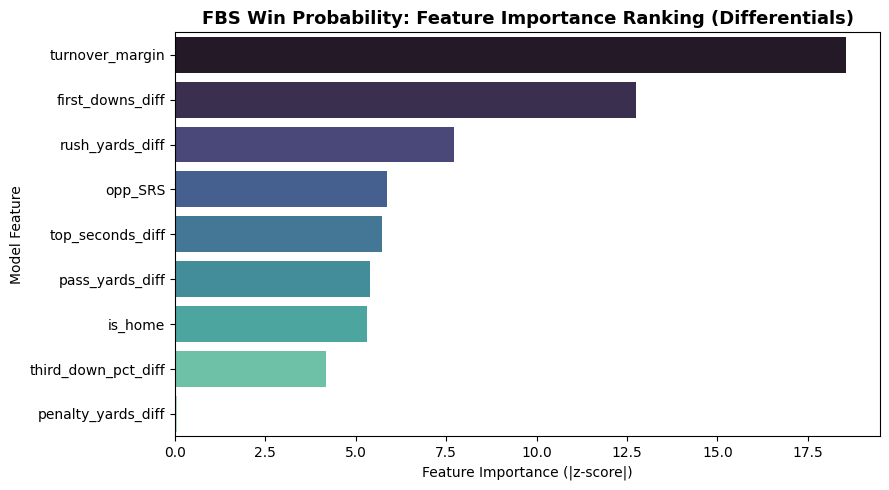

In [116]:
# Plot Feature Importance
plt.figure(figsize=(9, 5))
sns.barplot(data=summary_df, x="Importance (|z|)", y="Predictor", palette="mako")
plt.title("FBS Win Probability: Feature Importance Ranking (Differentials)", fontsize=13, fontweight="bold")
plt.xlabel("Feature Importance (|z-score|)")
plt.ylabel("Model Feature")
plt.tight_layout()
plt.show()

Changed the y test here because it is numerical and using class is boolean.

In [117]:
pred_probs_diff = logit_model_diff.predict(X_test_sm)
pred_class_diff = (pred_probs_diff >= 0.5).astype(int)
y_test_diff = (y_test >= 0.5).astype(int)
metrics_diff = pd.DataFrame({
    "Metric": ["Accuracy", "ROC AUC", "Log Loss", "Brier Score"],
    "Test Score": [
        accuracy_score(y_test_diff, pred_class_diff),
        roc_auc_score(y_test_diff, pred_probs_diff),
        log_loss(y_test_diff, pred_probs_diff),
        brier_score_loss(y_test_diff, pred_probs_diff)
    ]
})

print("Out-of-Sample Performance (Differentials Model):")
print(metrics_diff.to_string(index=False))

Out-of-Sample Performance (Differentials Model):
     Metric  Test Score
   Accuracy    0.804124
    ROC AUC    0.890779
   Log Loss    0.418208
Brier Score    0.136067


In [118]:
pred_probs_diff

1644    0.593984
1187    0.991589
1802    0.986841
1949    0.980596
1269    0.498940
          ...   
1330    0.176104
365     0.008608
412     0.073183
1724    0.093525
1011    0.001925
Length: 582, dtype: float64

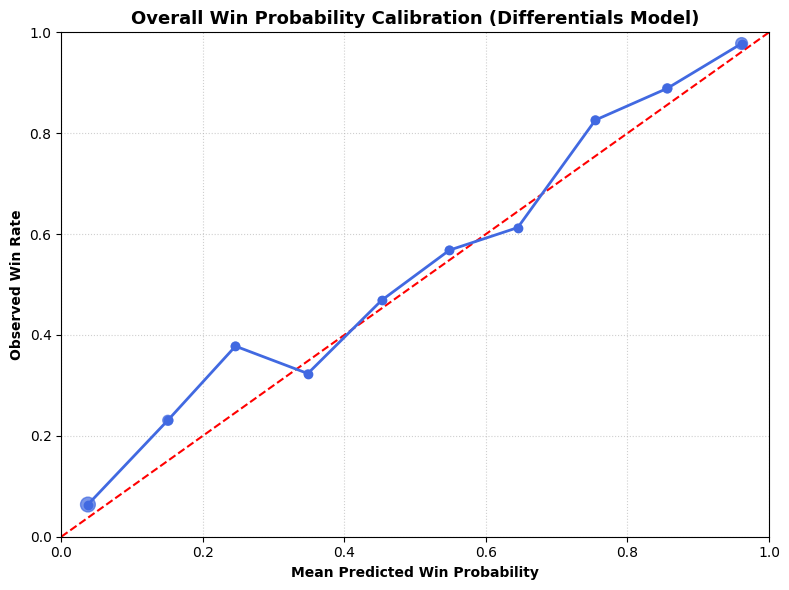

In [119]:
# Function for aggregate calibration plot
def plot_overall_calibration(y_true, y_probs, title_suffix=""):
    df_cal = pd.DataFrame({"actual": y_true, "pred": y_probs})
    df_cal["prob_bin"] = pd.cut(df_cal["pred"], bins=np.linspace(0, 1, 11), include_lowest=True)
    
    agg = df_cal.groupby("prob_bin", observed=False).agg(
        mean_pred=("pred", "mean"),
        actual_win_rate=("actual", "mean"),
        game_count=("actual", "count")
    ).reset_index().dropna()

    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Perfect Calibration")
    plt.plot(agg["mean_pred"], agg["actual_win_rate"], "o-", color="royalblue", linewidth=2)
    plt.scatter(agg["mean_pred"], agg["actual_win_rate"], s=agg["game_count"] * 0.8, color="royalblue", alpha=0.7)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Mean Predicted Win Probability", fontweight="bold")
    plt.ylabel("Observed Win Rate", fontweight="bold")
    plt.title(f"Overall Win Probability Calibration {title_suffix}", fontsize=13, fontweight="bold")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_overall_calibration(y_test, pred_probs_diff, "(Differentials Model)")

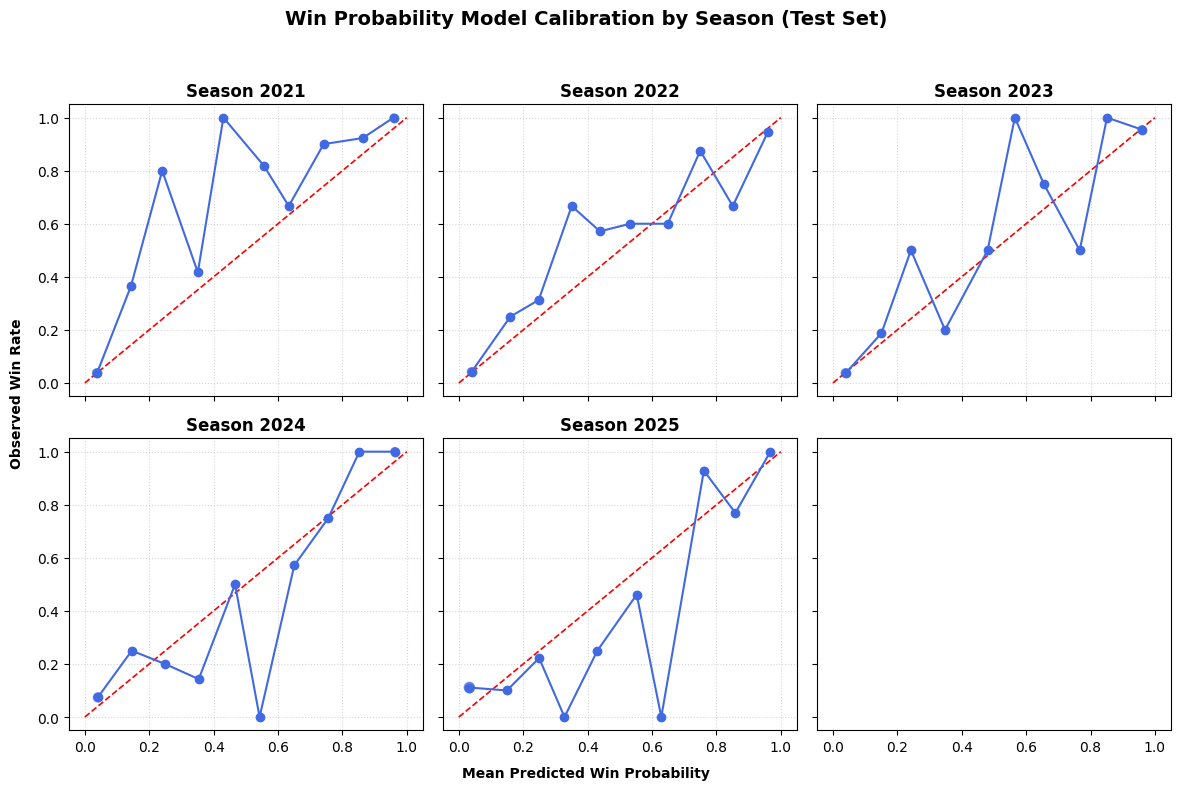

In [120]:
# Function for faceted season calibration plots
def plot_season_calibration(y_true, y_probs, seasons_series):
    df_cal = pd.DataFrame({"actual": y_true, "pred": y_probs, "season": seasons_series.values})
    df_cal["prob_bin"] = pd.cut(df_cal["pred"], bins=np.linspace(0, 1, 11), include_lowest=True)
    
    agg = df_cal.groupby(["season", "prob_bin"], observed=False).agg(
        mean_pred=("pred", "mean"),
        actual_win_rate=("actual", "mean"),
        game_count=("actual", "count")
    ).reset_index().dropna()

    unique_seasons = sorted(agg["season"].unique())
    fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for idx, s in enumerate(unique_seasons):
        ax = axes[idx]
        sub = agg[agg["season"] == s]
        ax.plot([0, 1], [0, 1], "r--", linewidth=1.2)
        ax.plot(sub["mean_pred"], sub["actual_win_rate"], "o-", color="royalblue", linewidth=1.5)
        ax.scatter(sub["mean_pred"], sub["actual_win_rate"], s=sub["game_count"] * 1.5, color="royalblue", alpha=0.7)
        ax.set_title(f"Season {s}", fontweight="bold")
        ax.grid(True, linestyle=":", alpha=0.5)

    plt.suptitle("Win Probability Model Calibration by Season (Test Set)", fontsize=14, fontweight="bold")
    fig.text(0.5, 0.02, "Mean Predicted Win Probability", ha="center", fontweight="bold")
    fig.text(0.02, 0.5, "Observed Win Rate", va="center", rotation="vertical", fontweight="bold")
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
    plt.show()

plot_season_calibration(y_test, pred_probs_diff, test_seasons)

Now do it for whole data set.

In [110]:
X_diff = cfb_diff[diff_predictors]
y_diff = cfb_diff["win"]

diff_indices = X_diff.index
diff_seasons = cfb_diff.loc[diff_indices, "season"]

# Standardizing features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_diff), columns=diff_predictors, index=X_diff.index)

# Add constant for statsmodels Logit
X_sm = sm.add_constant(X_scaled)

In [111]:
# Fit Logistic Regression Model
logit_model_diff = sm.Logit(y_diff, X_sm).fit(disp=False)

# Feature Importance Summary Table
summary_df = pd.DataFrame({
    "Predictor": logit_model_diff.params.index,
    "Std Beta": logit_model_diff.params.values,
    "Odds Ratio (1 SD)": np.exp(logit_model_diff.params.values),
    "z-statistic": logit_model_diff.tvalues.values,
    "p-value": logit_model_diff.pvalues.values
})
summary_df = summary_df[summary_df["Predictor"] != "const"].copy()
summary_df["Importance (|z|)"] = summary_df["z-statistic"].abs()
summary_df = summary_df.sort_values(by="Importance (|z|)", ascending=False)

print(summary_df.to_string(index=False))

          Predictor  Std Beta  Odds Ratio (1 SD)  z-statistic      p-value  Importance (|z|)
    turnover_margin  1.512456           4.537861    20.974077 1.131407e-97         20.974077
   first_downs_diff  1.140722           3.129027    14.135719 2.287841e-45         14.135719
    rush_yards_diff  0.496797           1.643449     8.419551 3.779313e-17          8.419551
   top_seconds_diff  0.349951           1.418998     6.311624 2.761232e-10          6.311624
            opp_SRS -0.346970           0.706826    -6.290766 3.159042e-10          6.290766
    pass_yards_diff -0.328805           0.719784    -6.087530 1.146656e-09          6.087530
            is_home  0.313149           1.367725     5.960996 2.507045e-09          5.960996
third_down_pct_diff  0.287176           1.332659     4.403264 1.066341e-05          4.403264
 penalty_yards_diff -0.004483           0.995527    -0.084098 9.329785e-01          0.084098


In [ ]:
# store model predictions in the variable 'predictions'
predictions = logit_model_diff.predict(X_sm)

0       0.028197
1       0.105175
2       0.518538
3       0.287731
4       0.654311
          ...   
2904    0.711268
2905    0.532761
2906    0.323891
2907    0.030094
2908    0.597954
Length: 2909, dtype: float64

In [ ]:
predictions - 1

In [ ]:
# make new diff and add predictions to it
cfb_diff_results = cfb_diff.copy()
cfb_diff_results['pos_team_predictions'] = predictions
cfb_diff_results['def_pos_team_predictions'] = predictions - 1